In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
#------------------------------------------
# 1. Load and Prepare the Data
#------------------------------------------


TrainingDF = pd.read_csv('./training_event_summary_with_m_inv.csv', sep =',', index_col=False)
X_NonExotic = pd.read_csv('./real_data_without_pentaquark.csv', sep =',', index_col=False)
X_Exotic = pd.read_csv('./real_data_with_pentaquark.csv', sep =',', index_col=False)


X=TrainingDF[['proton_PID_sum','kaon_PID_sum','pion_PID_sum','electron_PID_sum','muon_PID_sum', 'n_tracks']].values
# Extract mass separately
mass = TrainingDF['m_inv_pair'].values

# Create a train/test split

X_train, X_test, mass_train, mass_test = train_test_split(X, mass, test_size=0.05, random_state=42)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

import tensorflow as tf
print("TensorFlow version:", tf.version)
print("Available devices:", tf.config.list_physical_devices())
#tf.debugging.set_log_device_placement(True)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # Disable GPU (if any)
#------------------------------------------
# 2. Define the Autoencoder Model
#------------------------------------------

input_dim = X_train.shape[1] # should be 6
encoding_dim = 4 # latent space dimension
# Input layer

input_layer = Input(shape=(input_dim,))
# Encoding layer (compression)

encoded = Dense(encoding_dim, activation='relu')(input_layer)
# Decoding layer (reconstruction)

decoded = Dense(input_dim, activation='sigmoid')(encoded)
# Autoencoder model

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

from tensorflow.keras.optimizers import Adam
autoencoder.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
#autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse') # best, 185 epochs automatic stop
#------------------------------------------
#3. Training the Autoencoder
#------------------------------------------

early_stopping = EarlyStopping(
monitor='val_loss',
patience=2,
restore_best_weights=True
)

history = autoencoder.fit(X_train, X_train,
epochs=500,
# epochs=500,
batch_size=256,
# batch_size=64,
shuffle=True,
validation_data=(X_test, X_test),
verbose=2,
callbacks=[early_stopping]
)
#with tf.device('/CPU:0'):
#    history = autoencoder.fit(X_train, X_train,
#    epochs=500,
#    batch_size=64,
#    validation_data=(X_test, X_test),
#    callbacks=[early_stopping],
#    verbose=2)
#print(f"Training stopped at epoch {len(history.history['loss'])}")

print(f"Training stopped at epoch {len(history.history['loss'])}")

I0000 00:00:1780924943.912694   34137 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780924943.913083   34137 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780924943.946818   34137 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780924944.741275   34137 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

(114000, 6) (6000, 6)
TensorFlow version: <module 'tensorflow._api.v2.version' from '/home/student/KPacut/.venv/lib/python3.12/site-packages/tensorflow/_api/v2/version/__init__.py'>
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Epoch 1/500


E0000 00:00:1780924945.196656   34137 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


446/446 - 1s - 2ms/step - loss: 0.0352 - val_loss: 0.0099
Epoch 2/500
446/446 - 0s - 708us/step - loss: 0.0082 - val_loss: 0.0066
Epoch 3/500
446/446 - 0s - 604us/step - loss: 0.0059 - val_loss: 0.0045
Epoch 4/500
446/446 - 0s - 622us/step - loss: 0.0039 - val_loss: 0.0031
Epoch 5/500
446/446 - 0s - 676us/step - loss: 0.0028 - val_loss: 0.0024
Epoch 6/500
446/446 - 0s - 595us/step - loss: 0.0024 - val_loss: 0.0022
Epoch 7/500
446/446 - 0s - 661us/step - loss: 0.0022 - val_loss: 0.0020
Epoch 8/500
446/446 - 0s - 606us/step - loss: 0.0021 - val_loss: 0.0019
Epoch 9/500
446/446 - 0s - 620us/step - loss: 0.0020 - val_loss: 0.0018
Epoch 10/500
446/446 - 0s - 597us/step - loss: 0.0019 - val_loss: 0.0018
Epoch 11/500
446/446 - 0s - 582us/step - loss: 0.0019 - val_loss: 0.0018
Epoch 12/500
446/446 - 0s - 787us/step - loss: 0.0018 - val_loss: 0.0017
Epoch 13/500
446/446 - 0s - 931us/step - loss: 0.0018 - val_loss: 0.0017
Epoch 14/500
446/446 - 0s - 623us/step - loss: 0.0018 - val_loss: 0.0017
E

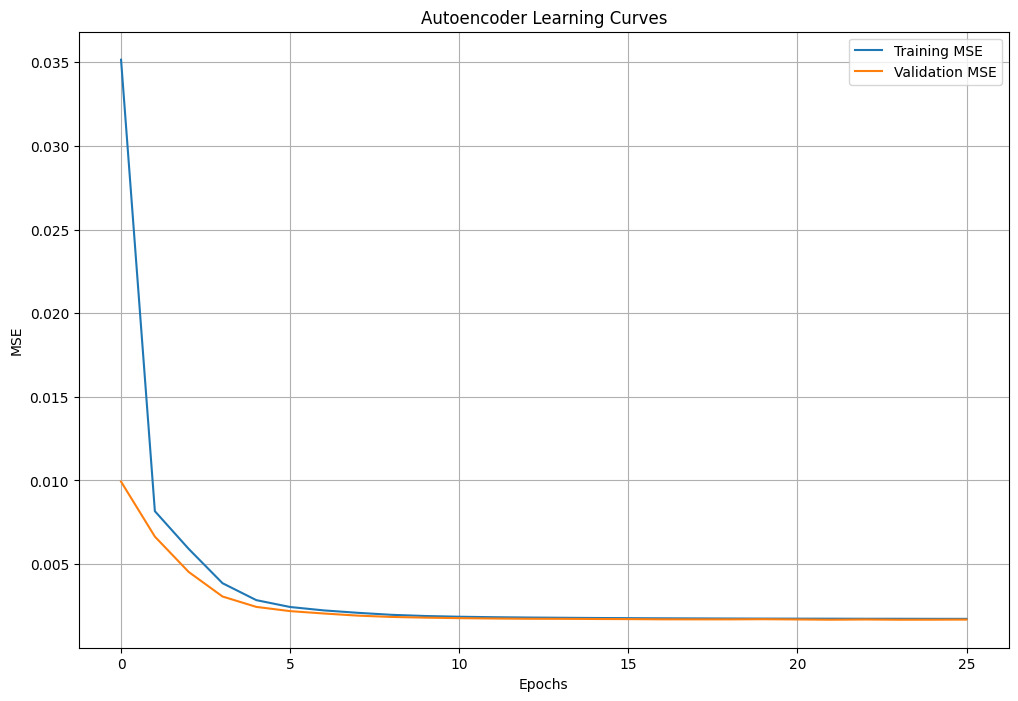

In [2]:


plt.figure(figsize=(12,8))

plt.plot(history.history['loss'], label='Training MSE')

plt.plot(history.history['val_loss'], label='Validation MSE')

#plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Autoencoder Learning Curves')
plt.legend()
plt.grid(True)

plt.show()

/home/student/KPacut/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/home/student/KPacut/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


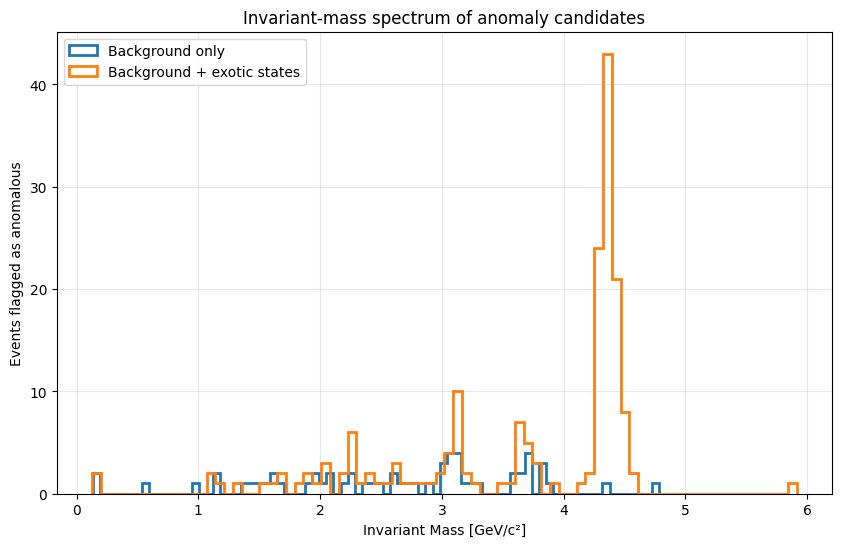

In [3]:
feature_cols = ['proton_PID_sum','kaon_PID_sum','pion_PID_sum','electron_PID_sum','muon_PID_sum', 'n_tracks']

# Background-only sample
sample_A = X_NonExotic

# Inclusive sample
sample_B = X_Exotic

# Scale
X_A_sc = scaler.transform(sample_A[feature_cols])
X_B_sc = scaler.transform(sample_B[feature_cols])

# Reconstruction
reco_A = autoencoder.predict(X_A_sc, verbose=0)
reco_B = autoencoder.predict(X_B_sc, verbose=0)

# MSE
mse_A = np.mean((X_A_sc - reco_A)**2, axis=1)
mse_B = np.mean((X_B_sc - reco_B)**2, axis=1)

# Threshold
threshold = np.percentile(mse_A, 90)

anom_A = sample_A[mse_A > threshold]
anom_B = sample_B[mse_B > threshold]

plt.figure(figsize=(10,6))

plt.hist(
    anom_A["m_inv_pair"],
    bins=80,
    histtype="step",
    linewidth=2,
    label="Background only"
)

plt.hist(
    anom_B["m_inv_pair"],
    bins=80,
    histtype="step",
    linewidth=2,
    label="Background + exotic states"
)

plt.xlabel("Invariant Mass [GeV/c²]")
plt.ylabel("Events flagged as anomalous")
plt.title("Invariant-mass spectrum of anomaly candidates")
plt.legend()
plt.grid(alpha=0.3)

plt.show()